# US Revenue Forecast — 조회 · 분석 · 시각화 노트북 v2

**소스 테이블** : `us_revenue_forecast_data`

### 성장률 측정 기준
| 구분 | 계산 방법 |
|------|----------|
| **4Q 성장률** | 예측 향후 4분기 합산 ÷ 직전 실제 4분기 합산 − 1 |
| **8Q 성장률** | 예측 향후 8분기 합산 ÷ 최근 실제 8분기 합산 − 1 |
| **기간 CAGR** | 기하평균 기반 연환산 성장률 |

---
| 셀 | 단계 |
|---|---|
| Cell 1 | 환경 설정 & 경로 자동 감지 |
| Cell 2 | 라이브러리 Import & DB 연결 |
| Cell 3 | 파라미터 설정 |
| Cell 4 | 핵심 계산 함수 정의 |
| Cell 5 | 단일 티커 예측치 조회 함수 |
| Cell 6 | 단일 티커 조회 테스트 + 증감률 표 |
| Cell 7 | Best-N 기업 추출 함수 |
| Cell 8 | Best-N 추출 테스트 |
| Cell 9 | 단일 티커 매출 전망 차트 |
| Cell 10 | Best-N 성장률 비교 막대 차트 |


## Cell 1 · 환경 설정 & 경로 자동 감지

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve()
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] root (자동 감지): {root}")
            return root
    for c in _CANDIDATE_ROOTS:
        if os.path.isdir(c):
            if c not in sys.path:
                sys.path.insert(0, c)
            print(f"[PATH] root (후보 경로): {c}")
            return c
    raise EnvironmentError("DATA 폴더를 찾을 수 없습니다. _CANDIDATE_ROOTS를 수정하세요.")

_root = _setup_path()
print(f"[확인] sys.path[0] = {sys.path[0]}")


[PATH] root (자동 감지): C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] sys.path[0] = C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\US_Market\analysis\미국전기업_매출_예측


## Cell 2 · 라이브러리 Import & DB 연결

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text

matplotlib.rcParams["font.family"]       = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from DATA.config import get_db_info, get_engine, log

db_info = get_db_info()
engine  = get_engine(db_info)

try:
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print("[OK] DB 연결 성공")
    print(f"     host={db_info['host']}  port={db_info['port']}  db={db_info['database']}")
except Exception as e:
    print(f"[FAIL] DB 연결 실패: {e}")


[OK] DB 연결 성공
     host=192.168.0.230  port=3307  db=investar


## Cell 3 · 파라미터 설정

이 셀만 수정해서 항목·모델·색상 등을 바꿀 수 있습니다.


In [3]:
DEST_TABLE = "us_revenue_forecast_data"
ITEM       = "sale"

ACTUAL_COLOR   = "#2C3E50"
FORECAST_COLOR = "#E74C3C"
BAR_PALETTE    = [
    "#2ECC71","#3498DB","#9B59B6","#F39C12","#E74C3C",
    "#1ABC9C","#E67E22","#34495E","#E91E63","#00BCD4",
    "#8BC34A","#FF5722","#607D8B","#795548","#9C27B0",
    "#03A9F4","#CDDC39","#FF9800","#673AB7","#009688",
]

print("[OK] 파라미터 설정 완료")


[OK] 파라미터 설정 완료


## Cell 4 · 핵심 계산 함수 정의

```
4Q 성장률  = (예측 향후 4Q 합산) / (직전 실제 4Q 합산) - 1
8Q 성장률  = (예측 향후 8Q 합산) / (최근 실제 8Q 합산) - 1
CAGR       = (말기값 / 기초값)^(1/n_years) - 1   (n_years = 분기수/4)
```


In [4]:
def calc_growth_4q(actual_vals: list, forecast_vals: list):
    '''4Q 성장률: 예측 향후 4Q 합산 / 직전 실제 4Q 합산 - 1'''
    if len(actual_vals) < 4 or len(forecast_vals) < 4:
        return None
    base   = sum(actual_vals[-4:])
    target = sum(forecast_vals[:4])
    if base == 0:
        return None
    return (target / base - 1) * 100


def calc_growth_8q(actual_vals: list, forecast_vals: list):
    '''8Q 성장률: 예측 향후 8Q 합산 / 최근 실제 8Q 합산 - 1'''
    if len(actual_vals) < 8 or len(forecast_vals) < 8:
        return None
    base   = sum(actual_vals[-8:])
    target = sum(forecast_vals[:8])
    if base == 0:
        return None
    return (target / base - 1) * 100


def calc_cagr(start_val: float, end_val: float, n_quarters: int):
    '''기하평균 기반 CAGR (연환산). n_quarters = 기간(분기 수)'''
    if start_val is None or end_val is None:
        return None
    if start_val <= 0 or end_val <= 0 or n_quarters <= 0:
        return None
    n_years = n_quarters / 4.0
    return ((end_val / start_val) ** (1.0 / n_years) - 1) * 100


def calc_qoq(prev_val: float, curr_val: float):
    '''단순 QoQ 증감률 (연환산 아님)'''
    if prev_val is None or prev_val == 0:
        return None
    return (curr_val / prev_val - 1) * 100


def unit_divisor(max_val: float):
    '''값 크기에 따른 단위 자동 결정 → (divisor, label)'''
    if max_val >= 1e12: return 1e12, "T"
    if max_val >= 1e9:  return 1e9,  "B"
    if max_val >= 1e6:  return 1e6,  "M"
    return 1, ""


def qtr_label(dt) -> str:
    '''datetime → YYYY\nQN 형식 레이블'''
    q = (dt.month - 1) // 3 + 1
    return f"{dt.year}\nQ{q}"

print("[OK] 계산 함수 정의 완료")


[OK] 계산 함수 정의 완료


## Cell 5 · 단일 티커 예측치 조회 함수

`fetch_forecast(ticker, model)` 반환값
- `actual_df` / `forecast_df` : 시계열 DataFrame
- `growth_df`  : 예측 구간 QoQ + 누적 CAGR 표
- `growth_4q`  : 4Q 성장률 (%)
- `growth_8q`  : 8Q 성장률 (%)
- `cagr_total` : 전체 예측 기간 CAGR (%/yr)


In [5]:
def fetch_forecast(
    ticker: str,
    model: str,
    item: str = ITEM,
    forecast_date: str = None,
) -> dict:
    '''
    us_revenue_forecast_data 에서 actual + forecast 를 조회하고
    4Q/8Q 성장률 및 CAGR 을 계산해 반환합니다.
    '''
    # forecast_date 자동 선택
    if forecast_date is None:
        sql_fd = (
            "SELECT MAX(forecast_date) FROM {tbl} "
            "WHERE ticker=:t AND item=:i"
        ).format(tbl=DEST_TABLE)
        with engine.connect() as conn:
            row = conn.execute(text(sql_fd), {"t": ticker, "i": item}).fetchone()
        if row is None or row[0] is None:
            raise ValueError(f"[{ticker}] '{item}' 데이터가 없습니다.")
        forecast_date = str(row[0])

    # actual 조회
    sql_act = (
        "SELECT date, value FROM {tbl} "
        "WHERE ticker=:t AND item=:i AND model='actual' AND forecast_date=:fd "
        "ORDER BY date"
    ).format(tbl=DEST_TABLE)
    with engine.connect() as conn:
        act = pd.read_sql(text(sql_act),
                          conn, params={"t": ticker, "i": item, "fd": forecast_date})

    # forecast 조회
    sql_fc = (
        "SELECT date, value FROM {tbl} "
        "WHERE ticker=:t AND item=:i AND model=:m "
        "  AND data_type='forecast' AND forecast_date=:fd "
        "ORDER BY date"
    ).format(tbl=DEST_TABLE)
    with engine.connect() as conn:
        fc = pd.read_sql(text(sql_fc),
                         conn, params={"t": ticker, "i": item,
                                       "m": model, "fd": forecast_date})

    if fc.empty:
        raise ValueError(f"[{ticker}] model='{model}' 예측 데이터가 없습니다.")

    act["date"]  = pd.to_datetime(act["date"])
    fc["date"]   = pd.to_datetime(fc["date"])
    act["value"] = act["value"].astype(float)
    fc["value"]  = fc["value"].astype(float)

    act_vals = act["value"].tolist()
    fc_vals  = fc["value"].tolist()

    # 성장률 계산
    g4       = calc_growth_4q(act_vals, fc_vals)
    g8       = calc_growth_8q(act_vals, fc_vals)
    cagr_tot = calc_cagr(act_vals[-1], fc_vals[-1], len(fc_vals))

    # 행별 QoQ + 누적 CAGR 표
    rows = []
    prev = act_vals[-1]
    for i, (dt, v) in enumerate(zip(fc["date"], fc_vals)):
        qoq      = calc_qoq(prev, v)
        cum_cagr = calc_cagr(act_vals[-1], v, i + 1)
        rows.append({
            "분기"        : qtr_label(dt),
            "date"        : dt,
            "예측값"      : round(v, 0),
            "QoQ(%)"      : round(qoq, 2)      if qoq      is not None else None,
            "누적CAGR(%)": round(cum_cagr, 2) if cum_cagr is not None else None,
        })
        prev = v

    growth_df = pd.DataFrame(rows)

    return {
        "ticker"       : ticker,
        "model"        : model,
        "item"         : item,
        "forecast_date": forecast_date,
        "actual_df"    : act,
        "forecast_df"  : fc,
        "growth_df"    : growth_df,
        "growth_4q"    : round(g4,       2) if g4       is not None else None,
        "growth_8q"    : round(g8,       2) if g8       is not None else None,
        "cagr_total"   : round(cagr_tot, 2) if cagr_tot is not None else None,
    }

print("[OK] fetch_forecast 함수 정의 완료")


[OK] fetch_forecast 함수 정의 완료


## Cell 6 · 단일 티커 조회 테스트 + 증감률 표

`TEST_TICKER` / `TEST_MODEL` 을 원하는 값으로 변경하세요.


In [11]:
TEST_TICKER = "RTO"
TEST_MODEL  = "Theta"   # SARIMA / ETS / Prophet / LSTM / Theta / Ensemble

res = fetch_forecast(TEST_TICKER, TEST_MODEL)
div, unit = unit_divisor(res["actual_df"]["value"].max())

# 요약
print("=" * 65)
print(f"  Ticker        : {res['ticker']}")
print(f"  Model         : {res['model']}")
print(f"  forecast_date : {res['forecast_date']}")
print(f"  기준값(actual 마지막) : {res['actual_df']['value'].iloc[-1] / div:.2f} {unit}")
print("-" * 65)

def _fmt(v, suffix=""):
    return f"{v:+.2f}{suffix}" if v is not None else "N/A"

print(f"  4Q  성장률  (예측4Q합/실제직전4Q합-1) : {_fmt(res['growth_4q'], '%')}")
print(f"  8Q  성장률  (예측8Q합/실제최근8Q합-1) : {_fmt(res['growth_8q'], '%')}")
print(f"  전체 CAGR   (기하평균 연환산)          : {_fmt(res['cagr_total'], '%/yr')}")
print("=" * 65)

# 증감률 표
print()
print(f"  {'분기':<10} {'예측값':>20} {'QoQ(%)':>10} {'누적CAGR(%/yr)':>16}")
print("  " + "-" * 60)
for _, row in res["growth_df"].iterrows():
    q_s    = f"{row['QoQ(%)']:+.2f}%"       if row["QoQ(%)"]       is not None else "  -"
    cagr_s = f"{row['누적CAGR(%)']:+.2f}%"  if row["누적CAGR(%)"] is not None else "  -"
    print(f"  {row['분기'].replace(chr(10),' '):<10} "
          f"{row['예측값']:>20,.0f} {q_s:>10} {cagr_s:>16}")
print("=" * 65)


  Ticker        : RTO
  Model         : Theta
  forecast_date : 2026-04-03
  기준값(actual 마지막) : 3.53 B
-----------------------------------------------------------------
  4Q  성장률  (예측4Q합/실제직전4Q합-1) : +17.88%
  8Q  성장률  (예측8Q합/실제최근8Q합-1) : +39.01%
  전체 CAGR   (기하평균 연환산)          : +4.87%/yr

  분기                          예측값     QoQ(%)     누적CAGR(%/yr)
  ------------------------------------------------------------
  2026 Q1           3,567,924,672     +1.20%           +4.87%
  2026 Q1           3,610,579,892     +1.20%           +4.87%
  2026 Q1           3,653,745,064     +1.20%           +4.87%
  2026 Q1           3,697,426,283     +1.20%           +4.87%
  2026 Q1           3,741,629,720     +1.20%           +4.87%
  2026 Q1           3,786,361,617     +1.20%           +4.87%
  2026 Q1           3,831,628,293     +1.20%           +4.87%
  2026 Q1           3,877,436,140     +1.20%           +4.87%


## Cell 7 · Best-N 기업 추출 함수

`get_best_n(model, n, sort_by)` :
- `sort_by='4q'` → 4Q 성장률 기준 정렬
- `sort_by='8q'` → 8Q 성장률 기준 정렬 (default)


In [7]:
def get_best_n(
    model: str,
    n: int = 20,
    item: str = ITEM,
    forecast_date=None,          # str | list[str] | None
    sort_by: str = "8q",
) -> tuple:
    '''
    us_revenue_forecast_data 에서 4Q / 8Q 성장률 상위 N 기업 반환.

    forecast_date:
        - None         : DB에서 가장 최근 forecast_date 자동 선택 (기존 동작)
        - str          : 단일 날짜 (기존 동작)
        - list[str]    : 복수 날짜 → 날짜별 데이터를 합산 후
                         같은 ticker가 여러 날짜에 존재하면 가장 최근 forecast_date만 유지

    Returns: (best_df, used_dates)
        used_dates : 실제 조회에 사용된 날짜 리스트 (str list)
    '''
    if sort_by not in ("4q", "8q"):
        raise ValueError("sort_by 는 '4q' 또는 '8q' 이어야 합니다.")

    # ── 1. forecast_date 정규화 ───────────────────────────────────────────
    if forecast_date is None:
        # 자동 선택 : 가장 최근 1개 날짜
        sql_fd = (
            "SELECT MAX(forecast_date) FROM {tbl} "
            "WHERE item=:i AND model=:m AND data_type='forecast'"
        ).format(tbl=DEST_TABLE)
        with engine.connect() as conn:
            row = conn.execute(text(sql_fd), {"i": item, "m": model}).fetchone()
        if row is None or row[0] is None:
            raise ValueError(f"model='{model}' 예측 데이터가 없습니다.")
        date_list = [str(row[0])]
    elif isinstance(forecast_date, str):
        date_list = [forecast_date]
    else:
        # list / tuple 등 iterable
        date_list = [str(d) for d in forecast_date]

    if not date_list:
        raise ValueError("forecast_date 가 빈 리스트입니다.")

    print(f"[INFO] forecast_dates={date_list}  model={model}  sort_by={sort_by.upper()}")

    # ── 2. IN 절 문자열 생성 (날짜 값은 따옴표로 감싸서 안전하게 삽입) ──────
    in_clause = ", ".join(f"'{d}'" for d in date_list)

    # ── 3. forecast 전체 조회 (forecast_date 컬럼 포함) ──────────────────
    sql_fc = (
        "SELECT ticker, date, value, forecast_date FROM {tbl} "
        "WHERE item=:i AND model=:m AND data_type='forecast' "
        "AND forecast_date IN ({fd_list}) "
        "ORDER BY ticker, forecast_date DESC, date"
    ).format(tbl=DEST_TABLE, fd_list=in_clause)
    with engine.connect() as conn:
        fc_all = pd.read_sql(text(sql_fc), conn, params={"i": item, "m": model})

    # ── 4. actual 전체 조회 (forecast_date 컬럼 포함) ────────────────────
    sql_act = (
        "SELECT ticker, date, value, forecast_date FROM {tbl} "
        "WHERE item=:i AND model='actual' "
        "AND forecast_date IN ({fd_list}) "
        "ORDER BY ticker, forecast_date DESC, date"
    ).format(tbl=DEST_TABLE, fd_list=in_clause)
    with engine.connect() as conn:
        act_all = pd.read_sql(text(sql_act), conn, params={"i": item})

    # ── 5. 타입 변환 ─────────────────────────────────────────────────────
    fc_all["date"]          = pd.to_datetime(fc_all["date"])
    act_all["date"]         = pd.to_datetime(act_all["date"])
    fc_all["forecast_date"] = pd.to_datetime(fc_all["forecast_date"])
    act_all["forecast_date"]= pd.to_datetime(act_all["forecast_date"])
    fc_all["value"]         = fc_all["value"].astype(float)
    act_all["value"]        = act_all["value"].astype(float)

    # ── 6. 중복 제거: 같은 ticker의 데이터가 여러 날짜에 있으면 최신만 유지 ──
    #    ORDER BY forecast_date DESC 로 조회했으므로
    #    (ticker, date) 기준 첫 번째 행 = 가장 최신 forecast_date 행
    fc_all  = fc_all.drop_duplicates(subset=["ticker", "date"], keep="first")
    act_all = act_all.drop_duplicates(subset=["ticker", "date"], keep="first")

    # ── 7. 실제 사용된 날짜 목록 집계 ────────────────────────────────────
    used_dates = sorted(
        fc_all["forecast_date"].dt.strftime("%Y-%m-%d").unique().tolist()
    )
    dup_tickers = (
        fc_all.groupby("ticker")["forecast_date"].nunique()
    )
    # (중복 제거 후이므로 이미 unique하지만, 원래 몇 개 날짜에서 왔는지 확인용)
    print(f"[INFO] 사용된 forecast_dates: {used_dates}")
    print(f"[INFO] 조회된 ticker 수: {fc_all['ticker'].nunique()}")

    # ── 8. 성장률 계산 ────────────────────────────────────────────────────
    rows = []
    for ticker, fc_grp in fc_all.groupby("ticker"):
        act_grp = act_all[act_all["ticker"] == ticker].sort_values("date")
        if act_grp.empty:
            continue
        fc_vals  = fc_grp.sort_values("date")["value"].tolist()
        act_vals = act_grp["value"].tolist()

        g4   = calc_growth_4q(act_vals, fc_vals)
        g8   = calc_growth_8q(act_vals, fc_vals)
        cagr = calc_cagr(act_vals[-1], fc_vals[-1], len(fc_vals))

        # 이 ticker의 실제 forecast_date 기록
        ticker_fd = fc_grp["forecast_date"].max().strftime("%Y-%m-%d")

        rows.append({
            "ticker"          : ticker,
            "forecast_date"   : ticker_fd,           # 어느 날 추정됐는지 추적용
            "act_sum_4q"      : round(sum(act_vals[-4:]), 0) if len(act_vals) >= 4 else None,
            "act_sum_8q"      : round(sum(act_vals[-8:]), 0) if len(act_vals) >= 8 else None,
            "fc_sum_4q"       : round(sum(fc_vals[:4]),  0) if len(fc_vals)  >= 4 else None,
            "fc_sum_8q"       : round(sum(fc_vals[:8]),  0) if len(fc_vals)  >= 8 else None,
            "growth_4q_pct"   : round(g4,   2) if g4   is not None else None,
            "growth_8q_pct"   : round(g8,   2) if g8   is not None else None,
            "cagr_total_pct"  : round(cagr, 2) if cagr is not None else None,
        })

    sort_col = "growth_4q_pct" if sort_by == "4q" else "growth_8q_pct"
    df = (
        pd.DataFrame(rows)
          .dropna(subset=[sort_col])
          .sort_values(sort_col, ascending=False)
          .head(n)
          .reset_index(drop=True)
    )
    df.index += 1
    return df, used_dates

print("[OK] get_best_n 함수 정의 완료")

[OK] get_best_n 함수 정의 완료


## Cell 8 · Best-N 추출 테스트

In [14]:
# ── Cell 8 · Best-N 추출 테스트 ──────────────────────────────────────────
BEST_MODEL  = "Ensemble"
BEST_N      = 175
BEST_SORTBY = "4q"      # "4q" 또는 "8q"

# 단일 날짜 (기존과 동일)
# best_df, used_fd = get_best_n(model=BEST_MODEL, n=BEST_N, sort_by=BEST_SORTBY)

# 복수 날짜 (2일치 합산, 중복은 최신 유지)
best_df, used_fd = get_best_n(
    model         = BEST_MODEL,
    n             = BEST_N,
    sort_by       = BEST_SORTBY,
    forecast_date = ["2026-04-03", "2026-04-04"],   # ← 날짜 리스트 전달
)

print(f"\n[매출 성장률 Top-{BEST_N}]  model={BEST_MODEL}  기준={BEST_SORTBY.upper()}")
print(f"forecast_dates = {used_fd}\n")   # used_fd 는 이제 리스트

def _pct(v):
    if v is None or (isinstance(v, float) and v != v): return "-"
    return f"{v:+.2f}%"

def _pct_yr(v):
    if v is None or (isinstance(v, float) and v != v): return "-"
    return f"{v:+.2f}%/yr"

display(
    best_df.style
    .format({
        "act_sum_4q"    : "{:,.0f}",
        "act_sum_8q"    : "{:,.0f}",
        "fc_sum_4q"     : "{:,.0f}",
        "fc_sum_8q"     : "{:,.0f}",
        "growth_4q_pct" : _pct,
        "growth_8q_pct" : _pct,
        "cagr_total_pct": _pct_yr,
    })
    .background_gradient(subset=["growth_4q_pct", "growth_8q_pct"], cmap="YlGn")
    .set_caption(f"매출 성장률 Top-{BEST_N} ({BEST_MODEL}, 정렬: {BEST_SORTBY.upper()})")
)


[INFO] forecast_dates=['2026-04-03', '2026-04-04']  model=Ensemble  sort_by=4Q
[INFO] 사용된 forecast_dates: ['2026-04-03', '2026-04-04']
[INFO] 조회된 ticker 수: 1864

[매출 성장률 Top-175]  model=Ensemble  기준=4Q
forecast_dates = ['2026-04-03', '2026-04-04']



,ticker,forecast_date,act_sum_4q,act_sum_8q,fc_sum_4q,fc_sum_8q,growth_4q_pct,growth_8q_pct,cagr_total_pct
1,CMRX,2026-04-04,"212,000","536,000","8,805,920","18,137,952",+4053.74%,+3283.95%,+548.79%/yr
2,DISH,2026-04-03,"3,290,519,485,000","3,304,964,974,000","20,701,557,617,850","63,598,673,389,615",+529.13%,+1824.34%,+98.94%/yr
3,KALV,2026-04-04,"75,043,000","75,043,000","458,255,405","1,269,953,701",+510.66%,+1592.30%,+98.42%/yr
4,RCAT,2026-04-03,"40,729,631","52,989,454","162,785,201","300,999,845",+299.67%,+468.04%,+43.84%/yr
5,TGTX,2026-04-03,"616,287,000","945,291,000","2,399,438,885","6,786,464,959",+289.34%,+617.92%,+124.24%/yr
6,BLU,2026-04-03,"3,173,348,693","3,173,364,693","12,019,843,043","44,094,188,008",+278.77%,+1289.51%,+180.67%/yr
7,INSM,2026-04-03,"606,423,000","970,130,000","2,070,416,916","6,908,035,206",+241.41%,+612.07%,+146.68%/yr
8,SAGE,2026-04-04,"70,410,000","167,654,000","184,622,690","384,696,469",+162.21%,+129.46%,+33.40%/yr
9,UNIT,2026-04-03,"2,234,541,000","3,401,468,000","5,843,836,787","22,450,663,327",+161.52%,+560.03%,+161.49%/yr
10,CSR,2026-04-04,"353,132,000","614,115,000","915,773,443","3,960,012,997",+159.33%,+544.83%,+189.29%/yr


In [13]:
best_df.iloc[100:]

,ticker,forecast_date,act_sum_4q,act_sum_8q,fc_sum_4q,fc_sum_8q,growth_4q_pct,growth_8q_pct,cagr_total_pct
101,FRO,2026-04-03,1.965104e+09,4.015489e+09,2.551555e+09,5.260217e+09,29.84,31.00,6.18
102,SCZM,2026-04-03,3.030707e+08,5.639771e+08,3.934047e+08,9.826954e+08,29.81,74.24,56.15
103,SQM,2026-04-03,4.588049e+09,9.116809e+09,5.945540e+09,1.303126e+10,29.59,42.94,20.18
104,SNPS,2026-04-03,8.007661e+09,1.407942e+10,1.035683e+10,2.201372e+10,29.34,56.35,12.52
105,RTO,2026-04-03,1.232579e+10,2.141389e+10,1.591684e+10,3.471740e+10,29.13,62.13,20.32
106,WELL,2026-04-03,1.066714e+10,1.852075e+10,1.376451e+10,3.004102e+10,29.04,62.20,18.08
107,ELVA,2026-04-04,6.796100e+07,1.116540e+08,8.699847e+07,1.912389e+08,28.01,71.28,19.70
108,SHOP,2026-04-03,1.155600e+10,2.043600e+10,1.479080e+10,3.260834e+10,27.99,59.56,21.00
109,RARE,2026-04-03,6.727210e+08,1.232951e+09,8.606592e+08,1.841711e+09,27.94,49.37,13.24
110,MNKD,2026-04-03,3.489660e+08,6.344700e+08,4.462954e+08,9.836257e+08,27.89,55.03,12.68


In [8]:
def plot_ticker_forecast(
    ticker: str,
    model: str,
    item: str = ITEM,
    forecast_date: str = None,
    figsize: tuple = (20, 7),
):
    '''단일 티커 actual + forecast 시각화 (Line + Bar)'''
    res = fetch_forecast(ticker, model, item, forecast_date)
    act = res["actual_df"].copy()
    fc  = res["forecast_df"].copy()
    gdf = res["growth_df"].copy()

    max_v     = max(act["value"].max(), fc["value"].max())
    div, unit = unit_divisor(max_v)
    act_v     = (act["value"] / div).tolist()
    fc_v      = (fc["value"]  / div).tolist()
    act_lbl   = [qtr_label(d) for d in act["date"]]
    fc_lbl    = [qtr_label(d) for d in fc["date"]]

    g4_s  = f"{res['growth_4q']:+.2f}%"     if res["growth_4q"]   is not None else "N/A"
    g8_s  = f"{res['growth_8q']:+.2f}%"     if res["growth_8q"]   is not None else "N/A"
    ca_s  = f"{res['cagr_total']:+.2f}%/yr" if res["cagr_total"] is not None else "N/A"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(
        f"{ticker}  |  {item.upper()} Revenue Forecast  "
        f"|  model: {model}  |  {res['forecast_date']}\n"
        f"4Q Growth: {g4_s}    8Q Growth: {g8_s}    CAGR: {ca_s}",
        fontsize=13, fontweight="bold", y=1.02
    )

    split   = len(act_v)
    all_v   = act_v + fc_v
    all_lbl = act_lbl + fc_lbl

    # ── (1) Line 차트 ─────────────────────────────────────
    ax1.plot(range(split), act_v,
             color=ACTUAL_COLOR, lw=2.2, marker="o", ms=4.5,
             label="Actual", zorder=3)
    ax1.plot(range(split - 1, len(all_v)), all_v[split - 1:],
             color=FORECAST_COLOR, lw=2.2, ls="--",
             marker="o", ms=4.5, label="Forecast", zorder=3)
    ax1.axvline(x=split - 1, color="gray", lw=1.0, ls=":", alpha=0.7)

    # 최근 8개 actual + 전체 forecast 에만 값 표시
    show_set = set(range(max(0, split - 8), split)) | set(range(split, len(all_v)))
    for i, v in enumerate(all_v):
        if i not in show_set:
            continue
        col = ACTUAL_COLOR if i < split else FORECAST_COLOR
        ax1.annotate(f"{v:.1f}{unit}", (i, v),
                     xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=7, color=col,
                     fontweight="bold" if i >= split else "normal")

    ax1.set_xticks(range(len(all_lbl)))
    ax1.set_xticklabels(all_lbl, fontsize=7)
    ax1.set_title("전체 흐름 (Actual + Forecast)", fontsize=11)
    ax1.set_ylabel(f"Revenue ({unit})", fontsize=10)
    ax1.legend(fontsize=9)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))
    ax1.grid(axis="y", ls="--", alpha=0.35)
    ax1.spines[["top", "right"]].set_visible(False)

    # ── (2) Bar 차트 (예측 구간) ──────────────────────────
    x    = list(range(len(fc_v)))
    bars = ax2.bar(x, fc_v, color=FORECAST_COLOR, alpha=0.82,
                   width=0.6, edgecolor="white", zorder=2)

    for i, (bar, v) in enumerate(zip(bars, fc_v)):
        # 값 레이블 (상단)
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(fc_v) * 0.013,
            f"{v:.1f}{unit}",
            ha="center", va="bottom", fontsize=8,
            fontweight="bold", color=FORECAST_COLOR
        )
        # QoQ 레이블 (막대 내부 하단)
        qoq = gdf["QoQ(%)"].iloc[i]
        if qoq is not None and qoq == qoq:
            clr = "#1A5276" if qoq >= 0 else "#922B21"
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 0.04,
                f"QoQ\n{qoq:+.1f}%",
                ha="center", va="bottom", fontsize=7,
                color=clr, fontweight="bold"
            )

    ax2.set_xticks(x)
    ax2.set_xticklabels(fc_lbl, fontsize=8)
    ax2.set_title(
        f"예측 구간  |  4Q:{g4_s}   8Q:{g8_s}   CAGR:{ca_s}",
        fontsize=10
    )
    ax2.set_ylabel(f"Revenue ({unit})", fontsize=10)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))
    ax2.grid(axis="y", ls="--", alpha=0.35)
    ax2.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

print("[OK] plot_ticker_forecast 함수 정의 완료")


[OK] plot_ticker_forecast 함수 정의 완료


### Cell 9 실행

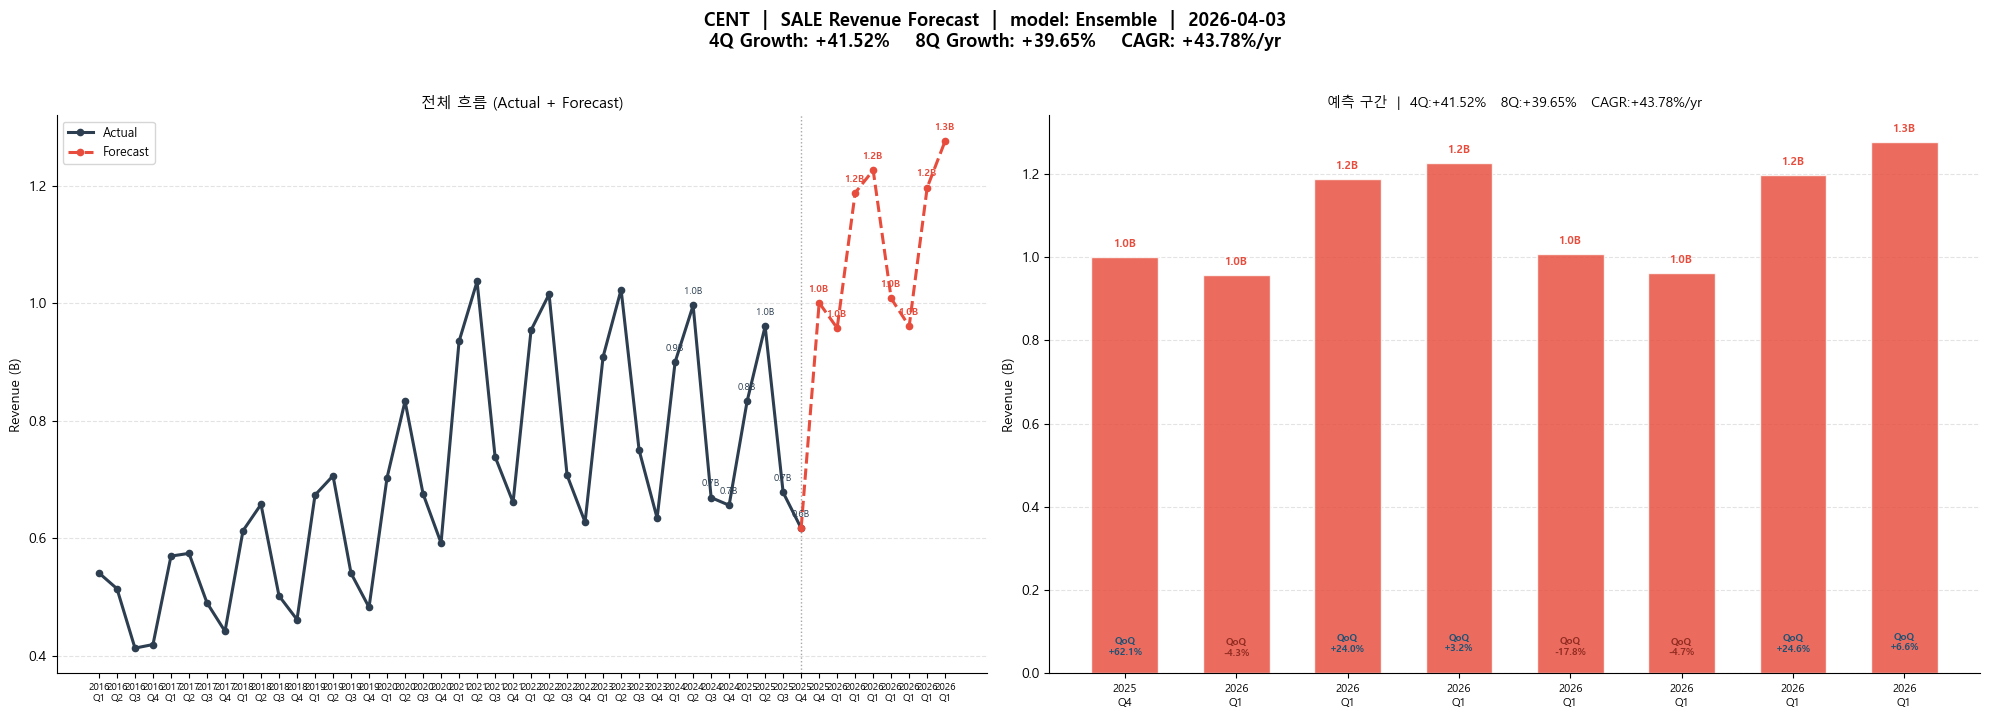

In [9]:
CHART_TICKER = "CENT"     # ← 변경
CHART_MODEL  = "Ensemble"  # ← 변경

plot_ticker_forecast(CHART_TICKER, CHART_MODEL)


## Cell 10 · Best-N 성장률 비교 막대 차트

**위 패널** : 향후 4분기 누적 성장률  
**아래 패널** : 향후 8분기 누적 성장률  
각 막대마다 성장률(%) 값이 표시됩니다.


In [11]:
def plot_best_n_growth(
    best_df: pd.DataFrame,
    model: str,
    forecast_date: str,
    top_n: int = None,
    w_per_bar: float = 0.72,
):
    '''Best-N 기업의 4Q / 8Q 성장률 상하 2패널 비교 차트'''
    df = best_df.head(top_n).copy() if top_n else best_df.copy()
    tickers = df["ticker"].tolist()
    n       = len(tickers)
    colors  = (BAR_PALETTE * 5)[:n]

    has_4q = df["growth_4q_pct"].notna().any()
    has_8q = df["growth_8q_pct"].notna().any()
    n_pnl  = int(has_4q) + int(has_8q)
    if n_pnl == 0:
        print("[WARN] 성장률 데이터가 없습니다.")
        return

    figw  = max(14, n * w_per_bar)
    fig, axes = plt.subplots(n_pnl, 1, figsize=(figw, 5.5 * n_pnl))
    if n_pnl == 1:
        axes = [axes]

    fig.suptitle(
        f"매출 성장률 Best-{n}  |  model: {model}  |  {forecast_date}\n"
        "4Q: 예측4Q합÷실제직전4Q합−1   "
        "8Q: 예측8Q합÷실제최근8Q합−1",
        fontsize=13, fontweight="bold"
    )

    def _draw(ax, raw_vals, title):
        vals = [v if (v is not None and v == v) else 0 for v in raw_vals]
        mx   = max(abs(v) for v in vals) if vals else 1

        bars = ax.bar(range(n), vals, color=colors,
                      alpha=0.88, width=0.65, edgecolor="white", zorder=2)

        for bar, v, orig in zip(bars, vals, raw_vals):
            if orig is None or orig != orig:
                continue
            offset = mx * 0.025
            ypos   = bar.get_height() + (offset if v >= 0 else -offset * 3.8)
            va     = "bottom" if v >= 0 else "top"
            ax.text(
                bar.get_x() + bar.get_width() / 2, ypos,
                f"{v:+.1f}%",
                ha="center", va=va, fontsize=8.5,
                fontweight="bold",
                color="#1A5276" if v >= 0 else "#922B21"
            )

        ax.axhline(0, color="gray", lw=0.9, ls="--", alpha=0.55)
        ax.set_xticks(range(n))
        ax.set_xticklabels(tickers, rotation=40, ha="right", fontsize=9)
        ax.set_ylabel("성장률 (%)", fontsize=10)
        ax.set_title(title, fontsize=12, fontweight="bold", pad=9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
        ax.grid(axis="y", ls="--", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    pi = 0
    if has_4q:
        _draw(axes[pi], df["growth_4q_pct"].tolist(),
              "향후 4분기 누적 성장률  (예측 4Q합 / 실제 직전 4Q합 − 1)")
        pi += 1
    if has_8q:
        _draw(axes[pi], df["growth_8q_pct"].tolist(),
              "향후 8분기 누적 성장률  (예측 8Q합 / 실제 최근 8Q합 − 1)")

    plt.tight_layout()
    plt.show()

print("[OK] plot_best_n_growth 함수 정의 완료")


[OK] plot_best_n_growth 함수 정의 완료


### Cell 10 실행

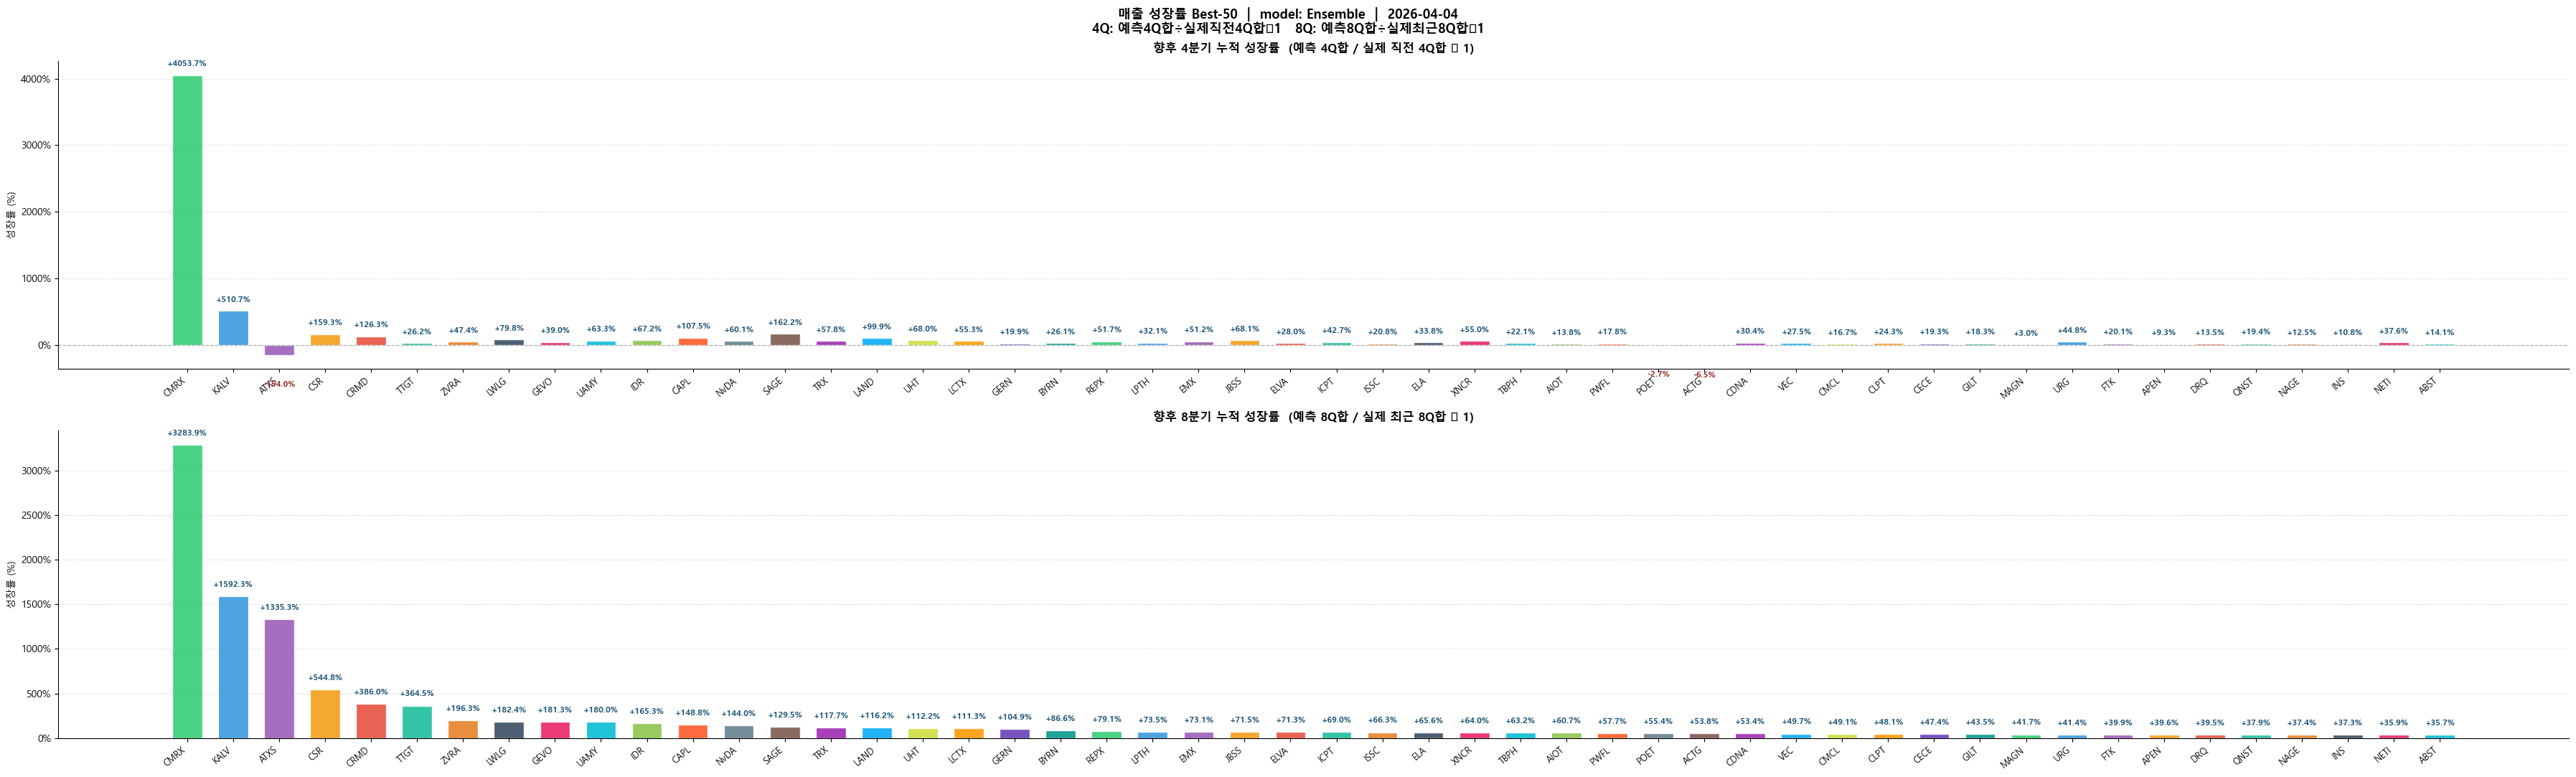

In [12]:
# Cell 8 에서 구한 best_df / used_fd 를 그대로 사용합니다.
# top_n 지정 시 상위 N개만 표시 (None → 전체)
plot_best_n_growth(
    best_df       = best_df,
    model         = BEST_MODEL,
    forecast_date = used_fd,
    top_n         = None,    # 예: 10
)
